In [24]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import roc_curve
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import linear_sum_assignment

def calculate_clustering_acc(y_true, y_pred):
    """计算聚类准确率 (基于匈牙利算法)"""
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    ind_row, ind_col = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(ind_row, ind_col)]) / y_pred.size

def find_eer_threshold(features, labels):
    """计算距离矩阵并寻找等错误率 (EER) 阈值"""
    dist_matrix = squareform(pdist(features, metric='euclidean'))
    n = len(labels)
    same_class_dists = []
    diff_class_dists = []
    
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                same_class_dists.append(dist_matrix[i, j])
            else:
                diff_class_dists.append(dist_matrix[i, j])
                
    y_true = [0] * len(same_class_dists) + [1] * len(diff_class_dists)
    y_scores = same_class_dists + diff_class_dists
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    return thresholds[eer_idx]

def run_sensitivity_analysis(features, labels, num_known_list, fixed_t=59.34, iterations=15):
    """运行敏感性分析：不同已知个体数量下的动态阈值 vs 固定阈值表现"""
    unique_ids = np.unique(labels)
    id_counts = {uid: np.sum(labels == uid) for uid in unique_ids}
    valid_ref_ids = [uid for uid, count in id_counts.items() if count >= 2]
    single_img_ids = [uid for uid, count in id_counts.items() if count == 1]
    
    print(f"=== 阈值敏感性与泛化性分析 (固定阈值 T={fixed_t}) ===")
    print(f"{'已知个体数':<10} | {'动态阈值 T (均值±标准差)':<25} | {'动态T 盲测准确率':<20} | {'固定T(59.34) 盲测准确率':<20}")
    print("-" * 85)
    
    for num_known in num_known_list:
        dynamic_thresholds = []
        acc_dynamic_list = []
        acc_fixed_list = []
        
        for _ in range(iterations):
            np.random.shuffle(valid_ref_ids)
            np.random.shuffle(single_img_ids)
            
            known_ids = valid_ref_ids[:num_known]
            unknown_ids = valid_ref_ids[num_known:] + single_img_ids
            
            known_mask = np.isin(labels, known_ids)
            unknown_mask = np.isin(labels, unknown_ids)
            
            X_known, y_known = features[known_mask], labels[known_mask]
            X_unknown, y_unknown = features[unknown_mask], labels[unknown_mask]
            
            # 1. 计算动态阈值
            t_dynamic = find_eer_threshold(X_known, y_known)
            dynamic_thresholds.append(t_dynamic)
            
            # 2. 在未知集上测试动态阈值
            Z_unknown = linkage(X_unknown, method='average')
            pred_dyn = fcluster(Z_unknown, t_dynamic, criterion='distance')
            acc_dynamic_list.append(calculate_clustering_acc(y_unknown, pred_dyn))
            
            # 3. 在未知集上测试固定阈值 (59.34)
            pred_fixed = fcluster(Z_unknown, fixed_t, criterion='distance')
            acc_fixed_list.append(calculate_clustering_acc(y_unknown, pred_fixed))
            
        # 统计结果
        mean_t = np.mean(dynamic_thresholds)
        std_t = np.std(dynamic_thresholds)
        mean_acc_dyn = np.mean(acc_dynamic_list) * 100
        mean_acc_fix = np.mean(acc_fixed_list) * 100
        
        print(f"{num_known:<10} | {mean_t:>6.2f} ± {std_t:<14.2f} | {mean_acc_dyn:>5.1f}%              | {mean_acc_fix:>5.1f}%")

if __name__ == "__main__":
    data = np.load('data_BC.npz')
    features = data['features']
    labels = data['labels']
    

    run_sensitivity_analysis(features, labels, num_known_list=[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28], fixed_t=59.34)

=== 阈值敏感性与泛化性分析 (固定阈值 T=59.34) ===
已知个体数      | 动态阈值 T (均值±标准差)           | 动态T 盲测准确率            | 固定T(59.34) 盲测准确率    
-------------------------------------------------------------------------------------
2          |  65.19 ± 5.18           |  70.9%              |  98.9%
3          |  61.38 ± 3.17           |  91.8%              |  98.9%
4          |  61.00 ± 3.40           |  91.6%              |  99.1%
5          |  59.70 ± 2.80           |  95.6%              |  99.2%
6          |  60.36 ± 2.41           |  95.4%              |  99.1%
7          |  58.90 ± 1.88           |  97.5%              |  99.2%
8          |  58.90 ± 1.93           |  97.4%              |  99.0%
9          |  59.08 ± 2.08           |  96.9%              |  99.1%
10         |  59.03 ± 1.49           |  98.2%              |  99.0%
11         |  59.22 ± 1.22           |  98.8%              |  98.8%
12         |  58.93 ± 1.60           |  98.7%              |  99.1%
13         |  59.17 ± 1.57           |  97.3% 

✅ Nature 风格高质量图片已生成: Fig_Threshold_Generalization.png


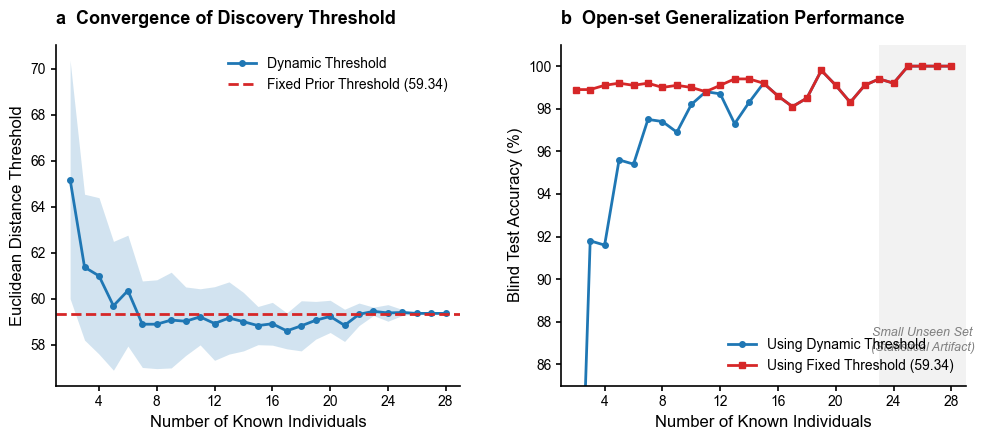

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ==========================================
# 1. Nature Journal 风格全局设置
# ==========================================
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
rcParams['axes.linewidth'] = 1.2
rcParams['xtick.major.width'] = 1.2
rcParams['ytick.major.width'] = 1.2
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['axes.labelsize'] = 12
rcParams['legend.fontsize'] = 10
rcParams['legend.frameon'] = False

# ==========================================
# 2. 数据提取 (基于你提供的表格)
# ==========================================
# 已知个体数
x = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

# 动态阈值 T 的均值与标准差
dynamic_t_mean = np.array([65.19, 61.38, 61.00, 59.70, 60.36, 58.90, 58.90, 59.08, 59.03, 59.22, 
                           58.93, 59.17, 59.01, 58.84, 58.92, 58.61, 58.83, 59.07, 59.24, 58.85, 
                           59.33, 59.46, 59.39, 59.41, 59.37, 59.37, 59.37])
dynamic_t_std = np.array([5.18, 3.17, 3.40, 2.80, 2.41, 1.88, 1.93, 2.08, 1.49, 1.22, 
                          1.60, 1.57, 1.27, 0.83, 0.93, 0.78, 1.09, 0.82, 0.70, 0.70, 
                          0.49, 0.18, 0.36, 0.13, 0.00, 0.00, 0.00])

# 盲测准确率 (%)
acc_dynamic = np.array([70.9, 91.8, 91.6, 95.6, 95.4, 97.5, 97.4, 96.9, 98.2, 98.8, 
                        98.7, 97.3, 98.3, 99.2, 98.6, 98.1, 98.5, 99.8, 99.1, 98.3, 
                        99.1, 99.4, 99.2, 100.0, 100.0, 100.0, 100.0])
acc_fixed = np.array([98.9, 98.9, 99.1, 99.2, 99.1, 99.2, 99.0, 99.1, 99.0, 98.8, 
                      99.1, 99.4, 99.4, 99.2, 98.6, 98.1, 98.5, 99.8, 99.1, 98.3, 
                      99.1, 99.4, 99.2, 100.0, 100.0, 100.0, 100.0])

# ==========================================
# 3. 开始绘图 (双子图并排排版)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
fig.patch.set_facecolor('white')

# 统一配色方案 (Nature 常用的深蓝与深红)
color_dynamic = '#1f77b4'  # 深蓝
color_fixed = '#d62728'    # 深红

# --------- 图 A: 阈值的敏感性与收敛 (左图) ---------
ax1.plot(x, dynamic_t_mean, color=color_dynamic, lw=2, marker='o', markersize=4, label='Dynamic Threshold')
# 绘制置信区间 (Error Band)
ax1.fill_between(x, dynamic_t_mean - dynamic_t_std, dynamic_t_mean + dynamic_t_std, 
                 color=color_dynamic, alpha=0.2, linewidth=0)
# 绘制固定的全局阈值基准线
ax1.axhline(y=59.34, color=color_fixed, linestyle='--', lw=2, label='Fixed Prior Threshold (59.34)')

ax1.set_xlabel('Number of Known Individuals')
ax1.set_ylabel('Euclidean Distance Threshold')
ax1.set_title('a  Convergence of Discovery Threshold', loc='left', fontweight='bold', fontsize=13, pad=15)
ax1.legend(loc='upper right')

# 清理边框
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(1, 29)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(4))

# --------- 图 B: 泛化准确率对比 (右图) ---------
ax2.plot(x, acc_dynamic, color=color_dynamic, lw=2, marker='o', markersize=4, label='Using Dynamic Threshold')
ax2.plot(x, acc_fixed, color=color_fixed, lw=2, marker='s', markersize=4, label='Using Fixed Threshold (59.34)')

# 截断 Y 轴，突出 90%-100% 这一核心区间
ax2.set_ylim(85, 101) 
ax2.set_xlabel('Number of Known Individuals')
ax2.set_ylabel('Blind Test Accuracy (%)')
ax2.set_title('b  Open-set Generalization Performance', loc='left', fontweight='bold', fontsize=13, pad=15)
ax2.legend(loc='lower right')

# 清理边框
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(1, 29)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(4))

# 标注一下极端稀疏区域（尾部样本量过小）
ax2.axvspan(23, 29, color='gray', alpha=0.1, lw=0)
ax2.text(26, 86.5, 'Small Unseen Set\n(Statistical Artifact)', ha='center', va='bottom', 
         fontsize=9, color='gray', fontstyle='italic')

# ==========================================
# 4. 调整布局并保存
# ==========================================
plt.tight_layout()
plt.subplots_adjust(wspace=0.25) # 调整两个子图之间的间距

output_filename = "Fig_Threshold_Generalization.png"
plt.savefig(output_filename, dpi=600, bbox_inches='tight')
print(f"✅ Nature 风格高质量图片已生成: {output_filename}")

统计完成：类内照片对 154 个，类间照片对 4796 个。
✅ 自然科学风格图像已保存为: Fig_Feature_Distribution_ROC.png (AUC = 0.9983)


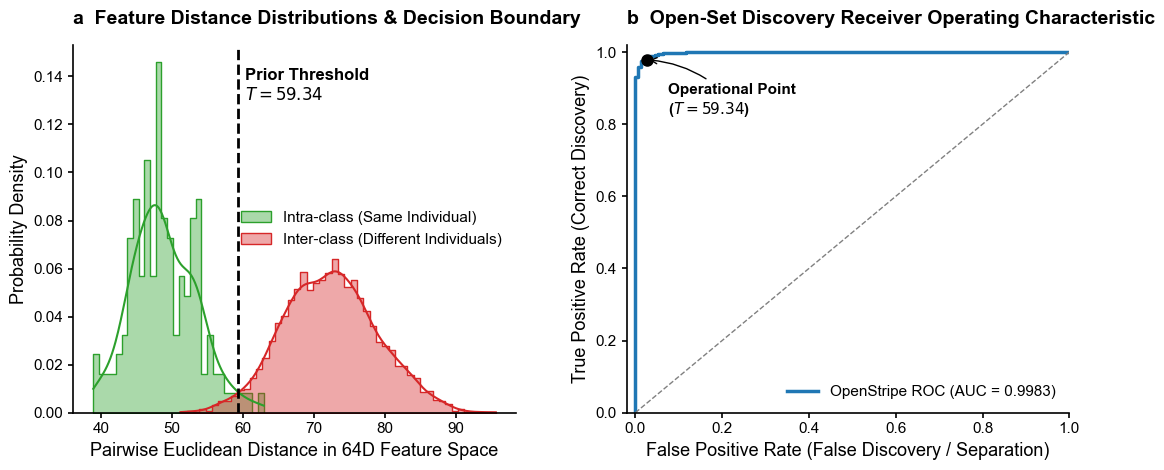

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.metrics import roc_curve, auc
from matplotlib import rcParams
import os



# ==========================================
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
rcParams['axes.linewidth'] = 1.2
rcParams['xtick.major.width'] = 1.2
rcParams['ytick.major.width'] = 1.2
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11
rcParams['axes.labelsize'] = 13
rcParams['legend.fontsize'] = 11
rcParams['legend.frameon'] = False

# ==========================================


data_file = 'data_BC.npz' 
if not os.path.exists(data_file):
    print(f"⚠️ 找不到文件 {data_file}，请确保文件名正确。")
    exit()

data = np.load(data_file)
features = data['features']  # 特征矩阵 (N, 64)
labels = data['labels']      # 真实标签 (N,)

distances = pdist(features, metric='euclidean')
n = len(labels)
iu1 = np.triu_indices(n, 1)

same_tiger = (labels[:, None] == labels[None, :])[iu1]

intra_dists = distances[same_tiger]
inter_dists = distances[~same_tiger]

print(f"统计完成：类内照片对 {len(intra_dists)} 个，类间照片对 {len(inter_dists)} 个。")

# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
fig.patch.set_facecolor('white')

TARGET_THRESHOLD = 59.34

# --------- 图 A: 距离分布直方图与 KDE 曲线 (左图) ---------
# 绘制类内距离 (同个体) - 绿色代表安全/匹配
sns.histplot(intra_dists, bins=30, kde=True, stat="density", 
             color="#2ca02c", element="step", alpha=0.4, 
             label="Intra-class (Same Individual)", ax=ax1)

# 绘制类间距离 (不同个体) - 红色/橙色代表排斥/不同
sns.histplot(inter_dists, bins=50, kde=True, stat="density", 
             color="#d62728", element="step", alpha=0.4, 
             label="Inter-class (Different Individuals)", ax=ax1)

# 画出 59.34 阈值的垂直切割线
ax1.axvline(x=TARGET_THRESHOLD, color='black', linestyle='--', linewidth=2, zorder=5)
ax1.text(TARGET_THRESHOLD + 1, ax1.get_ylim()[1] * 0.85, f'Prior Threshold\n$T={TARGET_THRESHOLD}$', 
         color='black', fontweight='bold', fontsize=12)

ax1.set_xlabel('Pairwise Euclidean Distance in 64D Feature Space')
ax1.set_ylabel('Probability Density')
ax1.set_title('a  Feature Distance Distributions & Decision Boundary', loc='left', fontweight='bold', fontsize=14, pad=15)
ax1.legend(loc='center right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --------- 图 B: 开放集 ROC 曲线 (右图) ---------
# 在开放集发现中，我们将“不同个体 (Discovery)”定义为正类 (Positive = 1)
# 距离越大，属于正类的得分越高
y_true = np.where(~same_tiger, 1, 0)
y_scores = distances

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
ax2.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'OpenStripe ROC (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # 随机猜测基准线

# 寻找 T=59.34 在曲线上的精确位置
idx = np.argmin(np.abs(roc_thresholds - TARGET_THRESHOLD))
fpr_at_T = fpr[idx]
tpr_at_T = tpr[idx]

# 标出 59.34 的工作点
ax2.plot(fpr_at_T, tpr_at_T, marker='o', markersize=8, color='black', zorder=5)
ax2.annotate(f'Operational Point\n($T={TARGET_THRESHOLD}$)', 
             xy=(fpr_at_T, tpr_at_T), xytext=(fpr_at_T + 0.05, tpr_at_T - 0.15),
             arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3,rad=0.2"),
             fontsize=11, fontweight='bold')

# 设置坐标轴 (注意：正类为“发现新个体”，所以 FPR 是过度分裂，TPR 是正确发现)
ax2.set_xlim([-0.02, 1.0])
ax2.set_ylim([0.0, 1.02])
ax2.set_xlabel('False Positive Rate (False Discovery / Separation)')
ax2.set_ylabel('True Positive Rate (Correct Discovery)')
ax2.set_title('b  Open-Set Discovery Receiver Operating Characteristic', loc='left', fontweight='bold', fontsize=14, pad=15)
ax2.legend(loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# 4. 渲染与高清晰度保存
# ==========================================
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)

output_img = "Fig_Feature_Distribution_ROC.png"
plt.savefig(output_img, dpi=600, bbox_inches='tight')
print(f"✅ 自然科学风格图像已保存为: {output_img} (AUC = {roc_auc:.4f})")